In [1]:
!pip install geopandas


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


In [3]:
fires = gpd.read_file('historic_perimeters.geojson')

In [4]:
fires.columns

Index(['OBJECTID', 'agency', 'comments', 'mapmethod', 'datecurrent',
       'uniquefireidentifier', 'fireyear', 'incidentname', 'pooownerunit',
       'perimeterdatetime', 'gisacres', 'complexname', 'firecode',
       'complexparentirwinid', 'pooresponsibleunit', 'state', 'inciwebid',
       'localincidentidentifier', 'irwinid', 'incomplex', 'complexfirecode',
       'geometry'],
      dtype='str')

In [5]:
co_fires = fires[fires['state']=='CO'].copy()
co_fires.head()

,OBJECTID,agency,comments,mapmethod,datecurrent,uniquefireidentifier,fireyear,incidentname,pooownerunit,perimeterdatetime,...,firecode,complexparentirwinid,pooresponsibleunit,state,inciwebid,localincidentidentifier,irwinid,incomplex,complexfirecode,geometry
2,3,C&L,WFDSS,Hand Sketch,"Mon, 24 Apr 2017 00:00:00 GMT",2017-CORBX-000061,2017,Milemarker 24,NaN,"Fri, 21 Apr 2017 00:00:00 GMT",...,NaN,NaN,CORBX,CO,NaN,000061,9c1a9e10-8fa8-4166-a212-eaf39a860469,N,NaN,"POLYGON ((-107.59472 40.00728, -107.59467 40.0..."
50,51,C&L,NaN,Mixed Methods,"Wed, 05 Jul 2017 00:00:00 GMT",2017-COGFX-000227,2017,Hog Back,NaN,"Mon, 03 Jul 2017 21:00:00 GMT",...,K3Y7,NaN,COGFX,CO,NaN,000227,46289058-1b84-40d2-b11c-0c7b0c6bb5c8,N,NaN,"POLYGON ((-107.50557 39.56233, -107.5031 39.56..."
123,124,BLM,Perimeter from FPER; GPS,GPS-Unknown Travel Method,"Mon, 14 Dec 2015 00:00:00 GMT",2015-COWRD-000374,2015,Frank,NaN,"Sun, 30 Aug 2015 00:00:00 GMT",...,J2XY,NaN,COWRD,CO,NaN,000374,9a5eab5a-57ba-4675-a772-9f9e3b8ab437,N,NaN,"MULTIPOLYGON (((-108.62754 40.20449, -108.6276..."
146,147,BLM,WFDSS GPS ground; named 'Steam Roller' in Fire...,GPS-Walked/ Driven,"Fri, 22 Jul 2011 00:00:00 GMT",2011-COWRD-000238,2011,Steamroller,NaN,"Thu, 21 Jul 2011 00:00:00 GMT",...,F7VM,NaN,COWRD,CO,NaN,000238,NaN,N,NaN,"POLYGON ((-108.42309 40.17229, -108.42306 40.1..."
151,152,BLM,GPS,GPS-Unknown Travel Method,"Mon, 30 Sep 2013 00:00:00 GMT",2011-COSLD-001112,2011,Mogote,NaN,"Mon, 11 Jul 2011 00:00:00 GMT",...,F63T,NaN,COSLD,CO,NaN,001112,NaN,N,NaN,"MULTIPOLYGON (((-106.17778 37.07495, -106.1776..."


In [6]:
fires_proj = co_fires.to_crs('EPSG:5070')

fires_proj['centroid']=fires_proj.geometry.centroid


In [7]:
centroids = gpd.GeoDataFrame(
    geometry = fires_proj['centroid'],
    crs=fires_proj.crs
)
centroids = centroids.to_crs('EPSG:4326')

In [8]:
co_fires['lat']=centroids.geometry.y
co_fires['lon']=centroids.geometry.x

co_fires[['incidentname','fireyear','lat','lon','gisacres','geometry']].head()

,incidentname,fireyear,lat,lon,gisacres,geometry
2,Milemarker 24,2017,40.001329,-107.593753,82.996239,"POLYGON ((-107.59472 40.00728, -107.59467 40.0..."
50,Hog Back,2017,39.558252,-107.502569,102.421582,"POLYGON ((-107.50557 39.56233, -107.5031 39.56..."
123,Frank,2015,40.204934,-108.630133,20.649229,"MULTIPOLYGON (((-108.62754 40.20449, -108.6276..."
146,Steamroller,2011,40.171827,-108.421984,2.605166,"POLYGON ((-108.42309 40.17229, -108.42306 40.1..."
151,Mogote,2011,37.074527,-106.171014,75.521856,"MULTIPOLYGON (((-106.17778 37.07495, -106.1776..."


In [9]:
co_fires = co_fires[['datecurrent', 'fireyear','incidentname','perimeterdatetime','gisacres','lat','lon','geometry']]
co_fires.head()

,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry
2,"Mon, 24 Apr 2017 00:00:00 GMT",2017,Milemarker 24,"Fri, 21 Apr 2017 00:00:00 GMT",82.996239,40.001329,-107.593753,"POLYGON ((-107.59472 40.00728, -107.59467 40.0..."
50,"Wed, 05 Jul 2017 00:00:00 GMT",2017,Hog Back,"Mon, 03 Jul 2017 21:00:00 GMT",102.421582,39.558252,-107.502569,"POLYGON ((-107.50557 39.56233, -107.5031 39.56..."
123,"Mon, 14 Dec 2015 00:00:00 GMT",2015,Frank,"Sun, 30 Aug 2015 00:00:00 GMT",20.649229,40.204934,-108.630133,"MULTIPOLYGON (((-108.62754 40.20449, -108.6276..."
146,"Fri, 22 Jul 2011 00:00:00 GMT",2011,Steamroller,"Thu, 21 Jul 2011 00:00:00 GMT",2.605166,40.171827,-108.421984,"POLYGON ((-108.42309 40.17229, -108.42306 40.1..."
151,"Mon, 30 Sep 2013 00:00:00 GMT",2011,Mogote,"Mon, 11 Jul 2011 00:00:00 GMT",75.521856,37.074527,-106.171014,"MULTIPOLYGON (((-106.17778 37.07495, -106.1776..."


In [10]:
co_fires['perimeterdatetime']=pd.to_datetime(co_fires['perimeterdatetime'], errors = 'coerce')
co_fires['datecurrent']=pd.to_datetime(co_fires['datecurrent'],errors = 'coerce')

co_fires[['perimeterdatetime', 'datecurrent']].dtypes

perimeterdatetime    datetime64[us]
datecurrent          datetime64[us]
dtype: object

In [11]:
co_fires.groupby(
    ['incidentname', 'fireyear']
).size().describe()

count    947.000000
mean       1.006336
std        0.091741
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64

In [12]:
co_fires.groupby(
    ['incidentname', 'fireyear']
).size().sort_values(ascending=False).head(20)

incidentname     fireyear
Lost Lakes       2002        3
West Fork        2013        2
Spring Creek     2002        2
Weber            2012        2
Willow           2012        2
PORPHYRY         2002        1
PRONG            2017        1
Pack Trail       2005        1
Pad              2007        1
Paladin          2004        1
Papoose          2013        1
Paradox          2008        1
Parkdale Canyon  2010        1
Patterson        2009        1
Payan Canyon     2011        1
Peak 2           2017        1
18 ROAD          2005        1
Piceance         2012        1
Picnic Rock      2004        1
Pie              2012        1
dtype: int64

In [13]:
co_fires[co_fires['incidentname']=='Lost Lakes']

,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry
18560,2002-09-09,2002,Lost Lakes,2002-09-08 15:00:00,3.829653,40.073165,-107.244799,"POLYGON ((-107.24559 40.07432, -107.24533 40.0..."
18779,2002-09-09,2002,Lost Lakes,2002-09-08 15:00:00,5528.611297,40.089537,-107.186640,"POLYGON ((-107.18876 40.09504, -107.18819 40.0..."
18934,2002-09-09,2002,Lost Lakes,2002-09-08 15:00:00,6.098701,40.090977,-107.254358,"POLYGON ((-107.25434 40.09181, -107.25417 40.0..."


In [14]:
idx = co_fires.groupby(
    ['incidentname','fireyear']
)['gisacres'].idxmax()

co_fires_final = co_fires.loc[idx].copy()
co_fires_final.groupby(
    ['incidentname', 'fireyear']
).size().sort_values(ascending=False).head(20)

incidentname     fireyear
18 ROAD          2005        1
Picnic Rock      2004        1
PRONG            2017        1
Pack Trail       2005        1
Pad              2007        1
Paladin          2004        1
Papoose          2013        1
Paradox          2008        1
Parkdale Canyon  2010        1
Patterson        2009        1
Payan Canyon     2011        1
Peak 2           2017        1
Petes Post       2001        1
Piceance         2012        1
Pie              2012        1
POLE             2017        1
Piedrosa Creek   2015        1
Pine             2010        1
Pine Ridge       2012        1
Pinion           2005        1
dtype: int64

In [15]:
print(co_fires_final.shape)
co_fires_final[['lat', 'lon']].head()

(947, 8)


,lat,lon
17896,39.262110,-108.705537
2209,39.246299,-108.700311
14292,39.261301,-108.714669
9156,40.748563,-107.756655
9355,39.208467,-108.654979


In [16]:
counties = gpd.read_file('counties.geojson')

In [17]:
print(counties.columns)
print(counties.crs)
counties.head()

Index(['OBJECTID', 'NAME', 'STATE_NAME', 'STATE_ABBR', 'STATE_FIPS',
       'COUNTY_FIPS', 'FIPS', 'POPULATION', 'POP_SQMI', 'SQMI', 'geometry'],
      dtype='str')
EPSG:4326


,OBJECTID,NAME,STATE_NAME,STATE_ABBR,STATE_FIPS,COUNTY_FIPS,FIPS,POPULATION,POP_SQMI,SQMI,geometry
0,1,Autauga County,Alabama,AL,01,001,01001,60428.0,100.0,604.37,"POLYGON ((-86.43963 32.70821, -86.42443 32.707..."
1,2,Baldwin County,Alabama,AL,01,003,01003,248832.0,152.4,1633.14,"MULTIPOLYGON (((-87.56491 30.28162, -87.5647 3..."
2,3,Barbour County,Alabama,AL,01,005,01005,24779.0,27.4,904.52,"POLYGON ((-85.25783 32.14793, -85.25836 32.146..."
3,4,Bibb County,Alabama,AL,01,007,01007,22252.0,35.5,626.17,"POLYGON ((-87.026 33.22252, -87.02598 33.22101..."
4,5,Blount County,Alabama,AL,01,009,01009,59594.0,91.6,650.63,"POLYGON ((-86.45302 34.25932, -86.45287 34.259..."


In [18]:
counties = counties.set_crs("EPSG:4326")

In [19]:
co_fires_final = gpd.GeoDataFrame(
    co_fires_final,
    geometry=gpd.points_from_xy(
        co_fires_final['lon'],
        co_fires_final['lat']
    ),
    crs="EPSG:4326"
)

co_fires_final = gpd.sjoin(
    co_fires_final,
    counties[['NAME', 'geometry']],
    how='left',
    predicate='intersects'
)

In [20]:
co_fires_final.head()

,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry,index_right,NAME
17896,2010-09-15,2005,18 ROAD,2005-07-16 19:37:00,17.511509,39.262110,-108.705537,POINT (-108.70554 39.26211),284,Mesa County
2209,2017-12-06,2017,18 Road,2017-05-27 00:00:00,0.707301,39.246299,-108.700311,POINT (-108.70031 39.2463),284,Mesa County
14292,2016-11-02,2016,18 Road Tracer,2016-07-18 00:00:00,0.123598,39.261301,-108.714669,POINT (-108.71467 39.2613),284,Mesa County
9156,2015-09-29,2015,20 Mile,2015-09-18 09:45:00,7.225905,40.748563,-107.756655,POINT (-107.75665 40.74856),286,Moffat County
9355,2017-12-06,2017,21 Road,2017-05-30 00:00:00,28.773811,39.208467,-108.654979,POINT (-108.65498 39.20847),284,Mesa County


In [21]:
co_fires_final['fire_date'] = pd.to_datetime(
    co_fires_final['perimeterdatetime'],
    errors='coerce'
)

co_fires_final['year'] = co_fires_final['fire_date'].dt.year
co_fires_final['month'] = co_fires_final['fire_date'].dt.month

In [22]:
!pip install cdsapi xarray netCDF4 pandas


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [23]:
from pathlib import Path
Path.home()

PosixPath('/Users/sofieappel')

In [24]:
import os

cds_config = """url: https://cds.climate.copernicus.eu/api
key: f39a1e52-7d22-41b3-8738-99e7d0a0b133
"""

config_path = Path.home() / ".cdsapirc"

with open(config_path, "w") as f:
    f.write(cds_config)

In [25]:
!pip install cdsapi


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [26]:
!pip install --upgrade xarray


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [27]:
!pip install --upgrade --force-reinstall netCDF4

  Using cached netcdf4-1.7.4-cp311-abi3-macosx_14_0_arm64.whl.metadata (2.1 kB)
  Using cached cftime-1.6.5-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.7 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached netcdf4-1.7.4-cp311-abi3-macosx_14_0_arm64.whl (22.8 MB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached certifi-2026.5.20-py3-none-any.whl (134 kB)
Using cached cftime-1.6.5-cp311-cp311-macosx_11_0_arm64.whl (492 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: certifi
    Found existing installation: certifi 2026.5.20
    Uninstalling certifi-2026.5.20:
      Successfully uninstalled certifi-2026.5.20
  Attempting uninstall: cftime
    Found existing installation: cftime 1.6.5
    Uninstalling cftime-1.6.5:
     

In [28]:
import xarray as xr

ds = xr.open_dataset("data_stream-mnth.nc")
print(ds)

<xarray.Dataset> Size: 52MB
Dimensions:     (valid_time: 1, latitude: 1801, longitude: 3600)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2020-08-02
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 26MB ...
    tp          (valid_time, latitude, longitude) float32 26MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T16:46 GRIB to CDM+CF via cfgrib-0.9.1...


In [29]:
ds.data_vars

Data variables:
    t2m      (valid_time, latitude, longitude) float32 26MB ...
    tp       (valid_time, latitude, longitude) float32 26MB ...

In [30]:
print(ds.latitude.min().values, ds.latitude.max().values)
print(ds.longitude.min().values, ds.longitude.max().values)

-90.0 90.0
0.0 359.9


In [31]:
co_fires_final["lon_adj"] = co_fires_final["lon"].apply(
    lambda x: x + 360 if x < 0 else x
)

In [32]:
def sample_fire(row):
    lat = row["lat"]
    lon = row["lon_adj"]

    point = ds.sel(
        latitude=lat,
        longitude=lon,
        method="nearest"
    )

    t2m = float(point["t2m"].values)
    tp = float(point["tp"].values)

    return t2m, tp

In [33]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "2m_temperature",
        "snow_cover",
        "total_precipitation"
    ],
    "year": [
        "2000", "2001", "2002",
        "2003", "2004", "2005",
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "download_format": "unarchived",
    "area": [41, 250.5, 37, 258]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2026-06-09 11:58:58,838 INFO Request ID is 87d180d3-4b5b-4887-a290-faf43f0fce0a
2026-06-09 11:58:59,028 INFO status has been updated to accepted
2026-06-09 11:59:13,182 INFO status has been updated to successful


'e87758b2af3cabd7893b403a2a6cdc86.grib'

In [34]:
!pip install cfgrib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [35]:
!pip install cfgrib eccodes


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [36]:
import cfgrib

In [37]:
print(cfgrib.__version__)

0.9.15.1


In [38]:
import eccodes
print(eccodes.__version__)

2.47.1


In [39]:
import sys
print(sys.executable)

import cfgrib
print(cfgrib.__version__)

import xarray as xr
print(xr.backends.list_engines())

/Users/sofieappel/Downloads/Project/.venv/bin/python
0.9.15.1
{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'cfgrib': <CfGribBackend>
  Open GRIB files (.grib, .grib2, .grb and .grb2) in Xarray
  Learn more at https://github.com/ecmwf/cfgrib, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [40]:
import xarray as xr

xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'cfgrib': <CfGribBackend>
   Open GRIB files (.grib, .grib2, .grb and .grb2) in Xarray
   Learn more at https://github.com/ecmwf/cfgrib,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}

In [41]:
import cfgrib
datasets = cfgrib.open_datasets("e87758b2af3cabd7893b403a2a6cdc86.grib")

Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file
Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file
Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file
Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file
Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file
Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.5b7b6.idx' older than GRIB file


In [42]:
tp_sets = [ds for ds in datasets if 'tp' in ds.data_vars]
for i, ds in enumerate(tp_sets):
    print(i, ds.time.min().values, ds.time.max().values, ds.time.size)

tp_full = xr.concat(tp_sets, dim="time").sortby("time")
tp_full

0 2000-01-01T00:00:00.000000000 2001-12-01T00:00:00.000000000 24
1 2002-01-01T00:00:00.000000000 2018-12-01T00:00:00.000000000 204


<xarray.Dataset> Size: 3MB
Dimensions:     (time: 228, latitude: 41, longitude: 76)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2018-12-01
    valid_time  (time) datetime64[ns] 2kB 2000-01-02 2000-02-02 ... 2018-12-02
  * latitude    (latitude) float64 328B 41.0 40.9 40.8 40.7 ... 37.2 37.1 37.0
  * longitude   (longitude) float64 608B 250.5 250.6 250.7 ... 257.8 257.9 258.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
Data variables:
    tp          (time, latitude, longitude) float32 3MB 0.0007681 ... 0.001356
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [43]:
t2m = xr.open_dataset(
    "e87758b2af3cabd7893b403a2a6cdc86.grib",
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "2t"}}
)

Ignoring index file 'e87758b2af3cabd7893b403a2a6cdc86.grib.47d85.idx' older than GRIB file


In [44]:
ds = xr.merge(
    [t2m, tp_full],
    join = 'inner',
    compat="override"
)

In [82]:
pt = ds.sel(
    latitude=39.7,
    longitude=360-105.0,
    method="nearest"
)

print(pt.tp.sel(time="2013-09-01").values)

0.0042094337


In [46]:
print(ds.t2m.dims)
print(ds.tp.dims)

('time', 'latitude', 'longitude')
('time', 'latitude', 'longitude')


In [47]:
lat = 39.7
lon = 360 - 105.0

pt = ds.sel(latitude=lat, longitude=lon, method="nearest")

float(pt.t2m.isel(time=0).values), float(pt.tp.isel(time=0).values)

(271.304443359375, 0.0009657661430537701)

In [48]:
def sample_fire(row):
    lat = row["lat"]
    lon = row["lon"]
    lon = lon + 360 if lon < 0 else lon

    pt = ds.sel(latitude=lat, longitude=lon, method="nearest")

    return {
        "t2m_mean": float(pt.t2m.mean("time")),
        "tp_sum": float(pt.tp.sum("time"))
    }

In [49]:
co_fires_final["lon_adj"] = co_fires_final["lon"].apply(
    lambda x: x + 360 if x < 0 else x
)

co_fires_final["date"] = pd.to_datetime(co_fires_final["perimeterdatetime"])

In [88]:
def extract_fire_features(row):

    lat = row["lat"]
    lon = row["lon_adj"]

    fire_month = row["date"].replace(day=1)

    pt = ds.sel(
        latitude=lat,
        longitude=lon,
        method="nearest"
    )

    pt = pt.sel(time=fire_month, method = 'nearest')

    return pd.Series({
        "temp_month": float(pt.t2m.values),
        "precip_month": float(pt.tp.values)
    })

In [89]:
co_fires_final = co_fires_final.reset_index(drop=True)

features_full = co_fires_final.apply(extract_fire_features, axis=1)

final_dataset = pd.concat(
    [co_fires_final, features_full],
    axis=1
)

In [91]:
final_dataset['temp_month'] = 1.8*(final_dataset['temp_month']-273.15)+32
final_dataset.head()

,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry,index_right,NAME,fire_date,year,month,lon_adj,date,temp_month,precip_month
0,2010-09-15,2005,18 ROAD,2005-07-16 19:37:00,17.511509,39.262110,-108.705537,POINT (-108.70554 39.26211),284,Mesa County,2005-07-16 19:37:00,2005,7,251.294463,2005-07-16 19:37:00,80.060176,0.000050
1,2017-12-06,2017,18 Road,2017-05-27 00:00:00,0.707301,39.246299,-108.700311,POINT (-108.70031 39.2463),284,Mesa County,2017-05-27 00:00:00,2017,5,251.299689,2017-05-27 00:00:00,61.228730,0.000890
2,2016-11-02,2016,18 Road Tracer,2016-07-18 00:00:00,0.123598,39.261301,-108.714669,POINT (-108.71467 39.2613),284,Mesa County,2016-07-18 00:00:00,2016,7,251.285331,2016-07-18 00:00:00,78.095381,0.000382
3,2015-09-29,2015,20 Mile,2015-09-18 09:45:00,7.225905,40.748563,-107.756655,POINT (-107.75665 40.74856),286,Moffat County,2015-09-18 09:45:00,2015,9,252.243345,2015-09-18 09:45:00,61.494160,0.000692
4,2017-12-06,2017,21 Road,2017-05-30 00:00:00,28.773811,39.208467,-108.654979,POINT (-108.65498 39.20847),284,Mesa County,2017-05-30 00:00:00,2017,5,251.345021,2017-05-30 00:00:00,61.228730,0.000890


In [92]:
final_dataset['precip_month']=final_dataset['precip_month']*39.3701
final_dataset.head()


,datecurrent,fireyear,incidentname,perimeterdatetime,gisacres,lat,lon,geometry,index_right,NAME,fire_date,year,month,lon_adj,date,temp_month,precip_month
0,2010-09-15,2005,18 ROAD,2005-07-16 19:37:00,17.511509,39.262110,-108.705537,POINT (-108.70554 39.26211),284,Mesa County,2005-07-16 19:37:00,2005,7,251.294463,2005-07-16 19:37:00,80.060176,0.001951
1,2017-12-06,2017,18 Road,2017-05-27 00:00:00,0.707301,39.246299,-108.700311,POINT (-108.70031 39.2463),284,Mesa County,2017-05-27 00:00:00,2017,5,251.299689,2017-05-27 00:00:00,61.228730,0.035027
2,2016-11-02,2016,18 Road Tracer,2016-07-18 00:00:00,0.123598,39.261301,-108.714669,POINT (-108.71467 39.2613),284,Mesa County,2016-07-18 00:00:00,2016,7,251.285331,2016-07-18 00:00:00,78.095381,0.015024
3,2015-09-29,2015,20 Mile,2015-09-18 09:45:00,7.225905,40.748563,-107.756655,POINT (-107.75665 40.74856),286,Moffat County,2015-09-18 09:45:00,2015,9,252.243345,2015-09-18 09:45:00,61.494160,0.027260
4,2017-12-06,2017,21 Road,2017-05-30 00:00:00,28.773811,39.208467,-108.654979,POINT (-108.65498 39.20847),284,Mesa County,2017-05-30 00:00:00,2017,5,251.345021,2017-05-30 00:00:00,61.228730,0.035027


In [93]:
final_dataset.to_csv("fire_climate_dataset.csv", index=False)

Text(0.5, 0, 'Acres Burned')

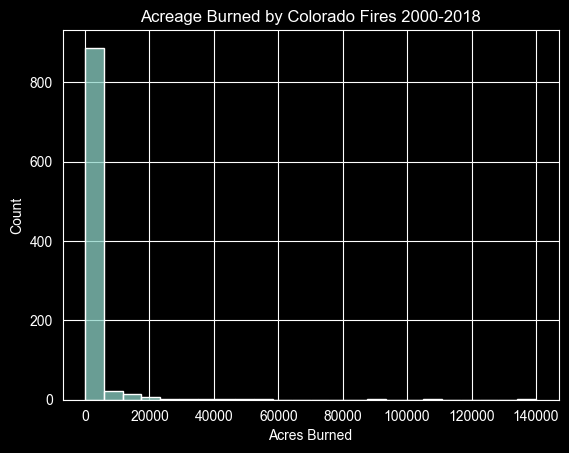

In [94]:

sns.histplot(data = final_dataset, x = 'gisacres', bins=np.linspace(0,140000,25))
plt.title('Acreage Burned by Colorado Fires 2000-2018')
plt.xlabel('Acres Burned')


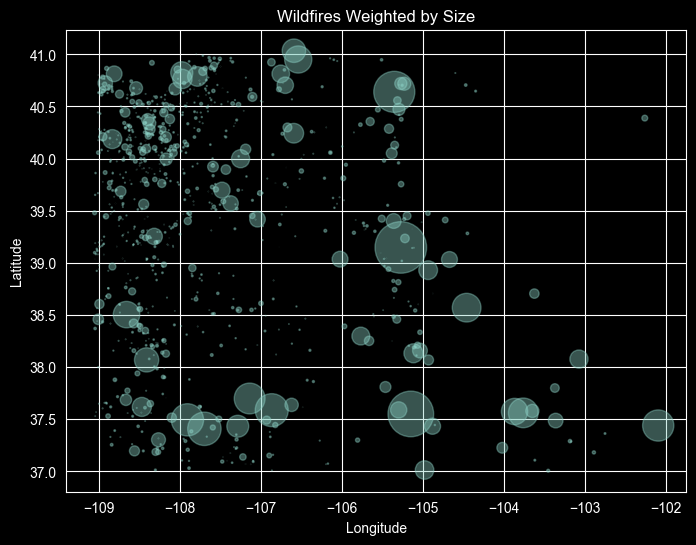

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_dataset["lon"],
    final_dataset["lat"],
    s=co_fires_final["gisacres"] / 100,  # scale
    alpha=0.4
)

plt.title("Wildfires Weighted by Size")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

(2000.0, 2018.0)

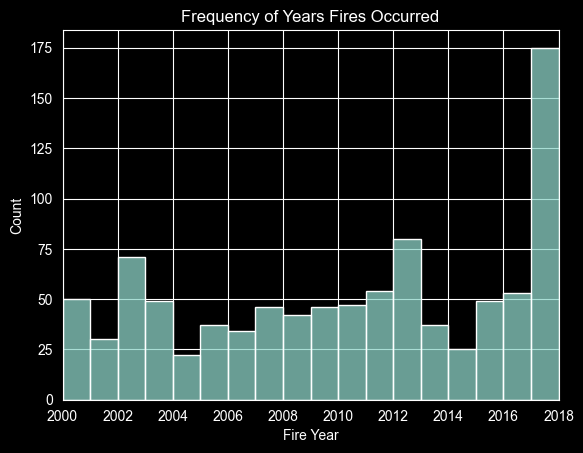

In [96]:
sns.histplot(data = final_dataset, x = 'fireyear', bins = 18)
plt.xlabel('Fire Year')
plt.title('Frequency of Years Fires Occurred')
plt.xlim(2000,2018)

Text(0.5, 0, 'Average Daily Precipitation by Month of Fire')

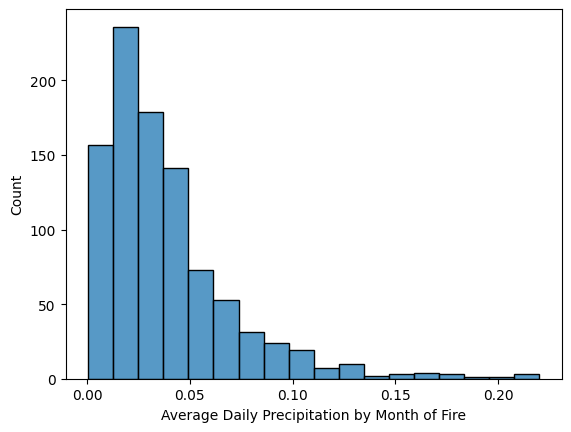

In [102]:
sns.histplot(data = final_dataset, x = 'precip_month', bins = 18)
plt.xlabel('Average Daily Precipitation by Month of Fire')


Text(0.5, 1.0, 'Acres Burned vs. Average Temperature (°F)')

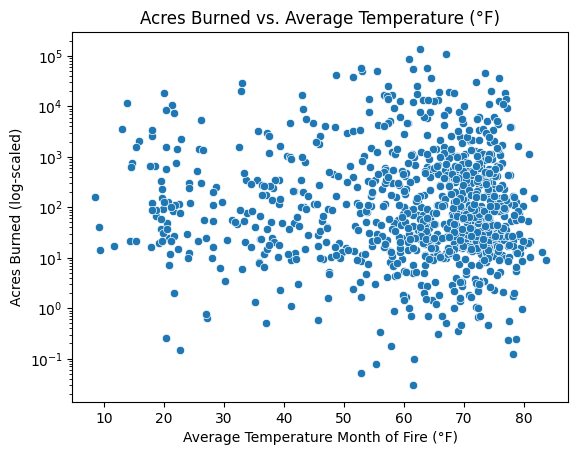

In [104]:
sns.scatterplot(data = final_dataset, y = 'gisacres', x = 'temp_month')
plt.yscale('log') 
plt.xlabel('Average Temperature Month of Fire (°F)')
plt.ylabel('Acres Burned (log-scaled)')
plt.title('Acres Burned vs. Average Temperature (°F)')

Text(0.5, 0, 'County')

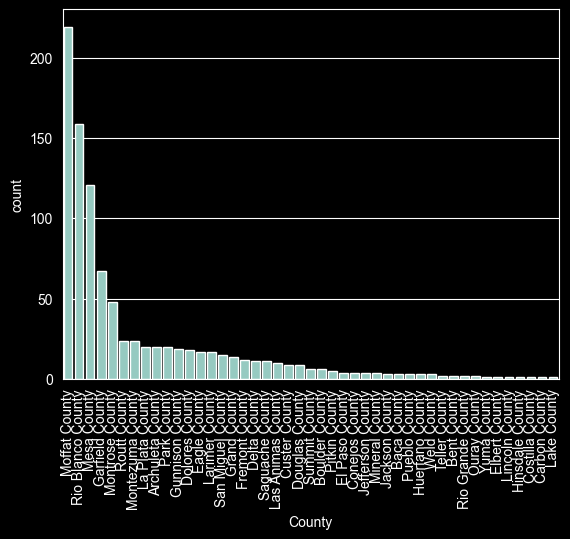

In [63]:
counts = pd.Series(final_dataset['NAME']).value_counts().sort_values(ascending=False)

desc_order = final_dataset['NAME'].value_counts().index

sns.countplot(final_dataset, x = 'NAME', order = desc_order)
plt.xticks(rotation=90)
plt.xlabel('County')

Text(0.5, 1.0, 'Fire Size vs. Time')

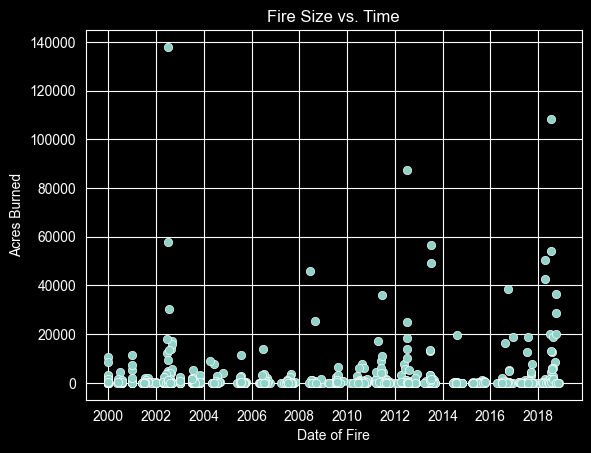

In [64]:
sns.scatterplot(final_dataset, x = 'perimeterdatetime',y='gisacres')
plt.xlabel('Date of Fire')
plt.ylabel('Acres Burned')
plt.title('Fire Size vs. Time')

Text(0.5, 1.0, 'Acres Burned vs. Average Precipitation')

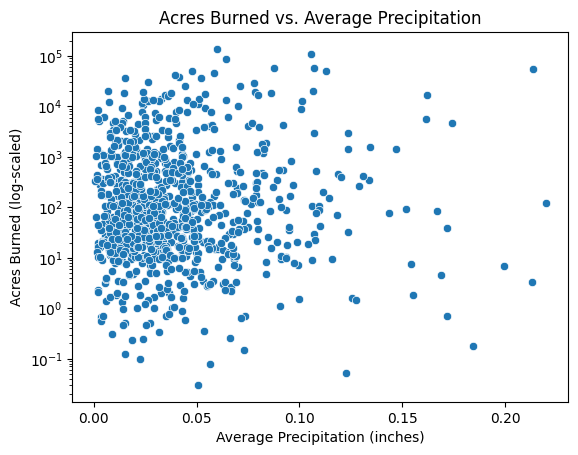

In [106]:
sns.scatterplot(data = final_dataset, y = 'gisacres', x = 'precip_month')
plt.yscale('log')
plt.xlabel('Average Precipitation (inches)')
plt.ylabel('Acres Burned (log-scaled)')
plt.title('Acres Burned vs. Average Precipitation')

([<matplotlib.axis.XTick at 0x3150b4f10>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

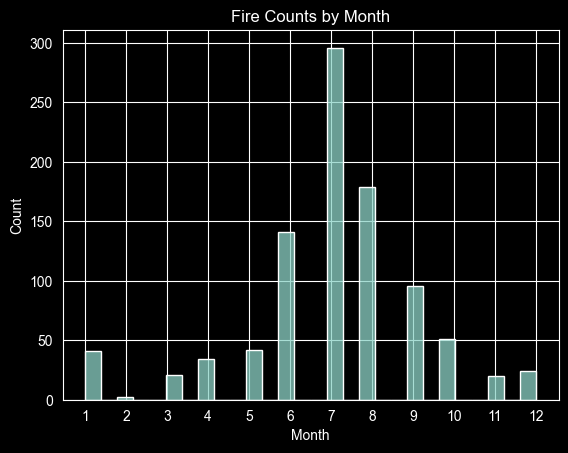

In [66]:
sns.histplot(final_dataset, x = 'month')
plt.xlabel('Month')
plt.title('Fire Counts by Month')
plt.xticks(np.arange(1, 13, 1))


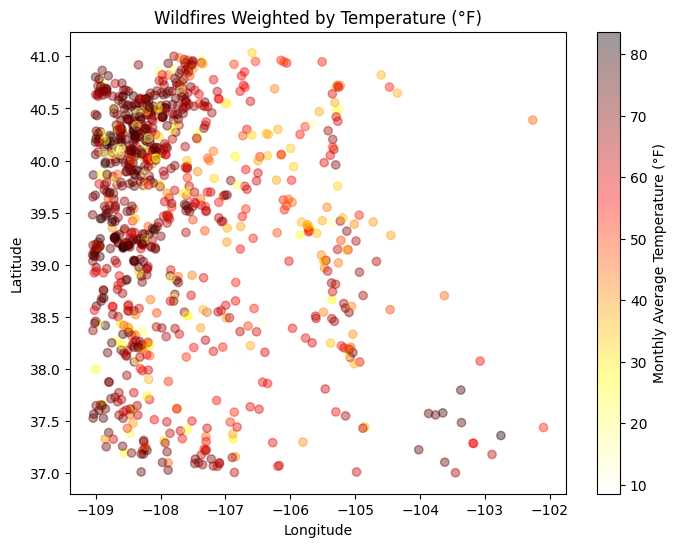

In [108]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_dataset["lon"],
    final_dataset["lat"],
    c=final_dataset["temp_month"],
    cmap = 'hot_r',
    alpha=0.4
)

plt.colorbar(label="Monthly Average Temperature (°F)")
plt.title("Wildfires Weighted by Temperature (°F)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

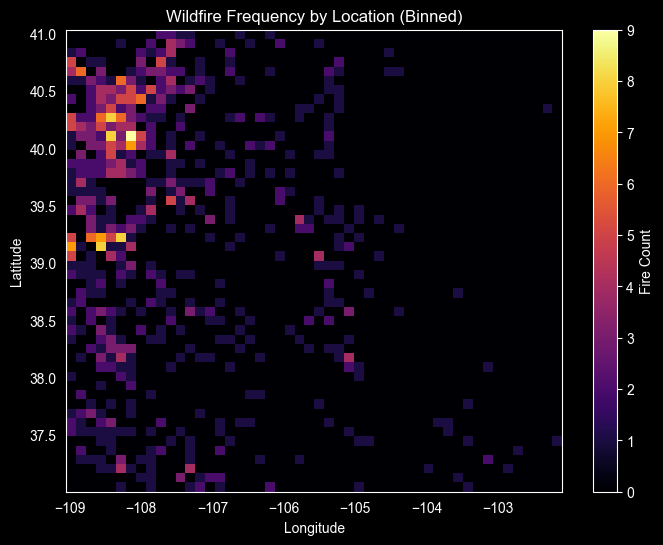

In [68]:
plt.figure(figsize=(8,6))

plt.hist2d(
    co_fires_final["lon"],
    co_fires_final["lat"],
    bins=50,
    cmap="inferno"
)

plt.colorbar(label="Fire Count")
plt.title("Wildfire Frequency by Location (Binned)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [69]:
final_dataset['precip_30d_sum'].describe()

count    943.000000
mean       0.039188
std        0.033048
min        0.000548
25%        0.016785
50%        0.030245
75%        0.049451
max        0.219858
Name: precip_30d_sum, dtype: float64